###  Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

### Set paths

In [5]:
# Move from src/notebooks → src
src_base_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

data_path = os.path.join(src_base_path, 'data', 'raw_data')
clean_data_path = os.path.join(src_base_path, 'data', 'clean_data')
output_path = os.path.join(src_base_path, 'outputs', 'charts')

# Create folders if they do not exist
os.makedirs(clean_data_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

print("Current working directory:", os.getcwd())
print("src base path:", src_base_path)
print("Raw data path:", data_path)
print("Clean data path:", clean_data_path)
print("Output path:", output_path)

print("\nFiles in raw_data folder:")
print(os.listdir(data_path))

Current working directory: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\notebooks
src base path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src
Raw data path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\raw_data
Clean data path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data
Output path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\outputs\charts

Files in raw_data folder:
['Access.xlsx', 'Affordability.xlsx', 'AI.xlsx', 'Digital.xlsx', 'Life.xlsx', 'National.xlsx']


### check sheet names in Life.xlsx

In [6]:
file_path = os.path.join(data_path, 'Life.xlsx')

excel_file = pd.ExcelFile(file_path)
print("Sheet names in Life.xlsx:")
print(excel_file.sheet_names)

Sheet names in Life.xlsx:
['Export']


###  Load raw data

In [7]:
df_raw = pd.read_excel(file_path, sheet_name='Export', header=None)

print("Raw dataset loaded successfully.")
print("Shape of raw dataset:", df_raw.shape)

Raw dataset loaded successfully.
Shape of raw dataset: (92, 8)


In [8]:
df_raw.head(20)

,0,1,2,3,4,5,6,7
0,"Thomas, J., McCosker, A., Parkinson, S., Hegar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All figures are weighted to the Australian pop...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Internet use,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Filters: none,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,View by: Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###  Inspect a wider section

This helps you understand where the useful tables begin.

In [9]:
df_raw.iloc[0:110, 0:10]

,0,1,2,3,4,5,6,7
0,"Thomas, J., McCosker, A., Parkinson, S., Hegar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All figures are weighted to the Australian pop...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Internet use,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
87,I am not confident using the internet,0.027444,0.012228,0.001427,0.003303,0.020657,0.062926,0.132746
88,I do not have convenient access to the internet,0.018207,0.010321,0.029216,0.009238,0.011232,0.027338,0.037675
89,Other,0.01699,0.018903,0.015299,0.011617,0.01825,0.009299,0.030884
90,I have a disability that restricts me from usi...,0.00418,0.000188,0.000551,0.012246,0.002264,0.002626,0.014176


###  Initial exploration

The raw Excel file contains multiple sections rather than a single clean table.  
From the initial inspection, the file appears to include:

- headings and explanatory labels
- grouped summary tables
- age-based percentages for different digital inclusion indicators

For this notebook, the two most relevant sections are:
1. barriers to internet use by age group
2. digital exclusion levels by age group

These sections are most relevant because they directly support the project problem statement around low confidence, digital exclusion, and difficulty using online services.

### Inspect likely exclusion section

In [10]:
exclusion_section = df_raw.iloc[10:25, 0:8]
exclusion_section

,0,1,2,3,4,5,6,7
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Digital exclusion,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,NaN,Highly excluded,Excluded,Included,Highly included,NaN,NaN,NaN
14,National average,0.092208,0.113687,0.372326,0.421779,NaN,NaN,NaN
15,18-34,0.017721,0.03811,0.340124,0.604046,NaN,NaN,NaN
16,35-44,0.02929,0.052096,0.331586,0.587028,NaN,NaN,NaN
17,45-54,0.060898,0.110026,0.342303,0.486773,NaN,NaN,NaN
18,55-64,0.091126,0.130941,0.49904,0.278893,NaN,NaN,NaN
19,65-74,0.158864,0.269574,0.443056,0.128506,NaN,NaN,NaN


### Create cleaned exclusion table

In [11]:
exclusion = pd.DataFrame({
    'Age Group': ['18–34', '35–44', '45–54', '55–64', '65–74', '75+'],
    'Highly Excluded': [0.0177, 0.0293, 0.0609, 0.0911, 0.1589, 0.4143],
    'Excluded':        [0.0381, 0.0521, 0.1100, 0.1309, 0.2696, 0.2512],
    'Included':        [0.3401, 0.3316, 0.3423, 0.4990, 0.4431, 0.3107],
    'Highly Included': [0.6040, 0.5870, 0.4868, 0.2789, 0.1285, 0.0238]
})

print("Cleaned digital exclusion table:")
print(exclusion)

Cleaned digital exclusion table:
  Age Group  Highly Excluded  Excluded  Included  Highly Included
0     18–34           0.0177    0.0381    0.3401           0.6040
1     35–44           0.0293    0.0521    0.3316           0.5870
2     45–54           0.0609    0.1100    0.3423           0.4868
3     55–64           0.0911    0.1309    0.4990           0.2789
4     65–74           0.1589    0.2696    0.4431           0.1285
5       75+           0.4143    0.2512    0.3107           0.0238


In [12]:
# Save cleaned exclusion table to CSV
exclusion_file_path = os.path.join(clean_data_path, 'digital_exclusion_by_age.csv')

exclusion.to_csv(exclusion_file_path, index=False)

print("Cleaned exclusion data saved successfully ")
print("File location:", exclusion_file_path)

Cleaned exclusion data saved successfully 
File location: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data\digital_exclusion_by_age.csv


In [13]:
print("Summary statistics:")
print(exclusion.describe())

Summary statistics:
       Highly Excluded  Excluded  Included  Highly Included
count         6.000000  6.000000  6.000000         6.000000
mean          0.128700  0.141983  0.377800         0.351500
std           0.148789  0.098215  0.075196         0.244912
min           0.017700  0.038100  0.310700         0.023800
25%           0.037200  0.066575  0.333725         0.166100
50%           0.076000  0.120450  0.341200         0.382850
75%           0.141950  0.221125  0.417900         0.561950
max           0.414300  0.269600  0.499000         0.604000


### Create extra column for total vulnerability

In [14]:
exclusion['Excluded or Highly Excluded'] = exclusion['Highly Excluded'] + exclusion['Excluded']

print(exclusion[['Age Group', 'Excluded or Highly Excluded']])

  Age Group  Excluded or Highly Excluded
0     18–34                       0.0558
1     35–44                       0.0814
2     45–54                       0.1709
3     55–64                       0.2220
4     65–74                       0.4285
5       75+                       0.6655


### Interpretation of exclusion data

A useful derived measure is the combined share of people who are either
'Highly Excluded' or 'Excluded'. This gives a clearer picture of digital vulnerability.

This is especially relevant for the target audience because the platform is intended
for older Australians with limited digital confidence.

### Plot exclusion chart

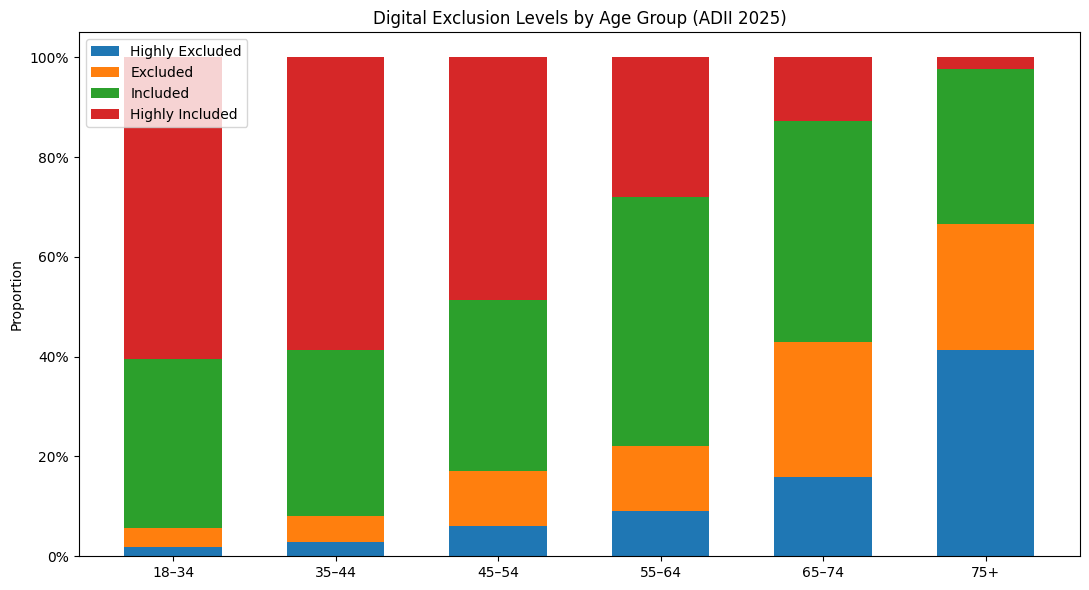

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(exclusion['Age Group']))
width = 0.6

ax.bar(x, exclusion['Highly Excluded'], width, label='Highly Excluded')
ax.bar(x, exclusion['Excluded'], width,
       bottom=exclusion['Highly Excluded'], label='Excluded')
ax.bar(x, exclusion['Included'], width,
       bottom=exclusion['Highly Excluded'] + exclusion['Excluded'], label='Included')
ax.bar(x, exclusion['Highly Included'], width,
       bottom=exclusion['Highly Excluded'] + exclusion['Excluded'] + exclusion['Included'],
       label='Highly Included')

ax.set_xticks(x)
ax.set_xticklabels(exclusion['Age Group'])
ax.set_ylabel('Proportion')
ax.set_title('Digital Exclusion Levels by Age Group (ADII 2025)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'digital_exclusion.png'), dpi=150, bbox_inches='tight')
plt.show()

###  Inspect likely barriers section

In [16]:
barrier_section = df_raw.iloc[75:95, 0:8]
barrier_section

,0,1,2,3,4,5,6,7
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,Main barriers to use,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,Barrier,Nat,18-34,35-44,45-54,55-64,65-74,75+
81,No barriers - I use the internet regularly and...,0.520599,0.623161,0.601246,0.540848,0.454647,0.384336,0.28986
82,I am concerned about privacy or scams,0.146325,0.09286,0.120684,0.130869,0.198049,0.194844,0.243958
83,My internet connection is too slow/unreliable,0.143893,0.162263,0.17821,0.152715,0.118943,0.116569,0.081054
84,The internet is not a priority for me,0.06975,0.016478,0.030542,0.050557,0.060642,0.1227,0.290811


### Create a clean barriers table

In [17]:
barriers = pd.DataFrame({
    'Barrier': [
        'No barriers',
        'Privacy / scam concern',
        'Slow or unreliable internet',
        'Not a priority',
        'Too expensive',
        'Not confident using internet',
        'No convenient access',
        'Disability restricts use'
    ],
    'National': [0.5206, 0.1463, 0.1439, 0.0698, 0.0604, 0.0274, 0.0182, 0.0042],
    '55–64':   [0.4546, 0.1980, 0.1189, 0.0606, 0.0648, 0.0207, 0.0112, 0.0023],
    '65–74':   [0.3843, 0.1948, 0.1166, 0.1227, 0.0458, 0.0629, 0.0273, 0.0026],
    '75+':     [0.2899, 0.2440, 0.0811, 0.2908, 0.0519, 0.1327, 0.0377, 0.0142]
})

print("Cleaned barriers table:")
print(barriers)

Cleaned barriers table:
                        Barrier  National   55–64   65–74     75+
0                   No barriers    0.5206  0.4546  0.3843  0.2899
1        Privacy / scam concern    0.1463  0.1980  0.1948  0.2440
2   Slow or unreliable internet    0.1439  0.1189  0.1166  0.0811
3                Not a priority    0.0698  0.0606  0.1227  0.2908
4                 Too expensive    0.0604  0.0648  0.0458  0.0519
5  Not confident using internet    0.0274  0.0207  0.0629  0.1327
6          No convenient access    0.0182  0.0112  0.0273  0.0377
7      Disability restricts use    0.0042  0.0023  0.0026  0.0142


In [19]:
# Save cleaned barriers table to CSV
barriers_file_path = os.path.join(clean_data_path, 'barriers_by_age.csv')

barriers.to_csv(barriers_file_path, index=False)

print("Cleaned barriers data saved successfully ")
print("File location:", barriers_file_path)

Cleaned barriers data saved successfully 
File location: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data\barriers_by_age.csv


### Explore barriers most relevant to the project

In [20]:
project_barriers = barriers[
    barriers['Barrier'].isin(['Privacy / scam concern', 'Not confident using internet'])
].copy()

print(project_barriers)

                        Barrier  National   55–64   65–74     75+
1        Privacy / scam concern    0.1463  0.1980  0.1948  0.2440
5  Not confident using internet    0.0274  0.0207  0.0629  0.1327


## Why focus on these barriers?

The project problem statement emphasises:
- uncertainty using digital platforms
- lack of confidence completing tasks independently

Therefore, the most relevant barriers for this project are:
- privacy concern and fear
- not confident using the internet

 Epic 1 and Epic 2  justify:
- official verified links
- plain-language explanations
- step-by-step task guidance

### Horizontal bar chart for barriers

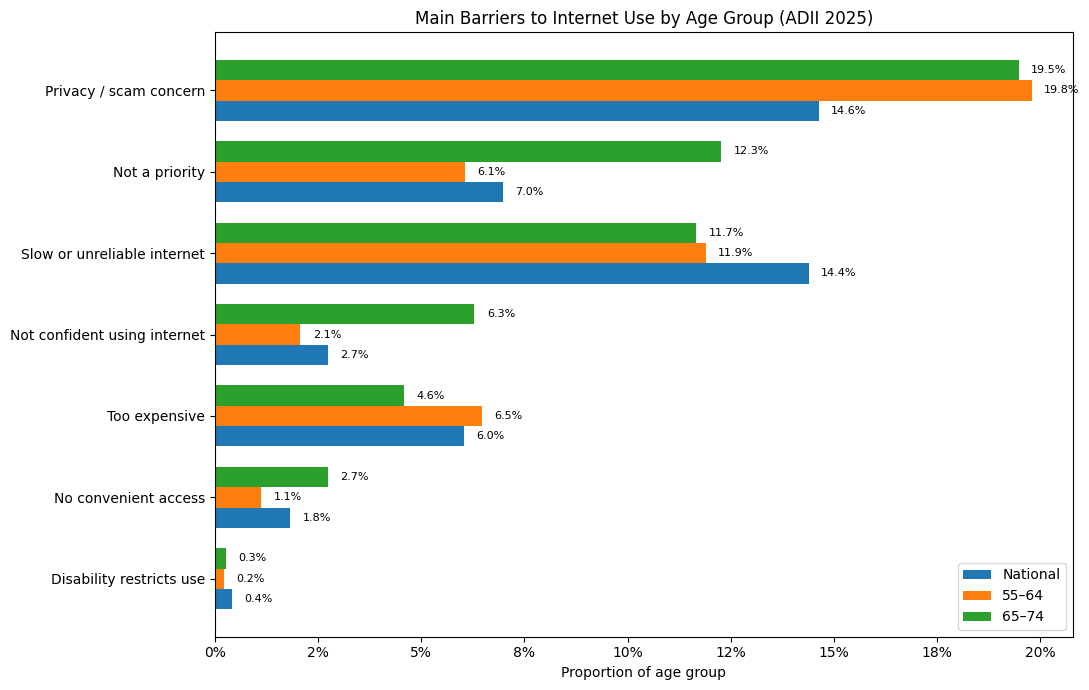

In [22]:
key_barriers = barriers[barriers['Barrier'] != 'No barriers'].copy()
key_barriers = key_barriers.sort_values(by='65–74', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

y = np.arange(len(key_barriers))
width = 0.25

bars1 = ax.barh(y - width, key_barriers['National'], width, label='National')
bars2 = ax.barh(y, key_barriers['55–64'], width, label='55–64')
bars3 = ax.barh(y + width, key_barriers['65–74'], width, label='65–74')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        value = bar.get_width()
        ax.text(value + 0.003, bar.get_y() + bar.get_height()/2,
                f'{value:.1%}', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(key_barriers['Barrier'])
ax.set_xlabel('Proportion of age group')
ax.set_title('Main Barriers to Internet Use by Age Group (ADII 2025)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'barriers_by_age.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("Charts currently saved:")
print(os.listdir(output_path))

print("\nClean data files currently saved:")
print(os.listdir(clean_data_path))

Charts currently saved:
['barriers_by_age.png', 'digital_ability_by_age.png', 'digital_exclusion.png']

Clean data files currently saved:
['access_connection.csv', 'access_devices.csv', 'access_frequency.csv', 'access_score.csv', 'access_time.csv', 'afford_10pct.csv', 'afford_compromised.csv', 'afford_sacrificed.csv', 'afford_score.csv', 'afford_subgroup.csv', 'barriers_by_age.csv', 'digital_ability_by_age.csv', 'digital_exclusion_by_age.csv', 'national_remoteness.csv', 'national_state.csv', 'national_time.csv']


### Short comparison calculation

In [24]:
scam_gap = barriers.loc[barriers['Barrier'] == 'Privacy / scam concern', '65–74'].values[0] - \
           barriers.loc[barriers['Barrier'] == 'Privacy / scam concern', 'National'].values[0]

confidence_gap = barriers.loc[barriers['Barrier'] == 'Not confident using internet', '65–74'].values[0] - \
                 barriers.loc[barriers['Barrier'] == 'Not confident using internet', 'National'].values[0]

print(f"Gap for privacy/scam concern (65–74 vs national): {scam_gap:.2%}")
print(f"Gap for low confidence (65–74 vs national): {confidence_gap:.2%}")

Gap for privacy/scam concern (65–74 vs national): 4.85%
Gap for low confidence (65–74 vs national): 3.55%


### Key findings

### Digital exclusion
The combined share of users who are either excluded or highly excluded increases with age.
This shows that older Australians are more digitally vulnerable than younger groups.

### Barriers to internet use
For older age groups, privacy and scam concern is a major barrier.
Low confidence using the internet also becomes more prominent with age.

### Relevance to the project
These findings directly support the need for:
- **Epic 1: Digital Services Directory**, because official and verified links can reduce trust concerns
- **Epic 2: Step-by-Step How-To Guides**, because users with low confidence benefit from structured visual guidance

Overall, the ADII data supports the project's focus on improving digital confidence and safe access to services for older Australians.

### Save the chart: Main Barriers to Internet Use by Age Group (ADII 2025)

In [25]:
print("Charts currently saved:")
print(os.listdir(output_path))

Charts currently saved:
['barriers_by_age.png', 'digital_ability_by_age.png', 'digital_exclusion.png']
